# DermoAI — MobileNetV2 FST V-VI Skin Lesion Classifier v2

## Project Objective

This notebook implements an AI-assisted dermatological triage system optimized for Fitzpatrick Skin Types (FST) V-VI (darker skin tones) in resource-limited settings in Rwanda. The system performs multi-class classification of skin lesions and routes cases to either **REFER** (urgent specialist referral) or **MANAGE LOCALLY** (primary care management).

## 7 Skin Condition Classes

| Class | Triage Decision |
|-------|----------------|
| `lichen_planus` | **MANAGE LOCALLY** |
| `lupus_erythematosus` | **REFER** |
| `pityriasis_rubra_pilaris` | **REFER** |
| `psoriasis` | **MANAGE LOCALLY** |
| `scabies` | **MANAGE LOCALLY** |
| `squamous_cell_carcinoma` | **REFER** |
| `vitiligo` | **MANAGE LOCALLY** |

**REFER classes:** Conditions requiring specialist referral (lupus_erythematosus, pityriasis_rubra_pilaris, squamous_cell_carcinoma)

**MANAGE LOCALLY classes:** Conditions treatable at primary care level (lichen_planus, psoriasis, scabies, vitiligo)

## Two-Phase Training Strategy

**Phase 1 — Feature Extraction (20 epochs)**
- Base MobileNetV2 frozen (ImageNet weights preserved)
- Train classification head only
- Learning rate: 1e-3
- REFER class weight: 2.0x

**Phase 2 — Fine-Tuning (15 epochs)**
- Unfreeze last 30 layers of MobileNetV2
- Fine-tune with lower learning rate: 1e-5
- REFER class weight: 3.0x (increased penalty for missed referrals)

## Performance Targets

- **Overall Accuracy:** ≥80% (minimum: 70%)
- **REFER Recall:** ≥75% (critical for patient safety)
- **Minimum Class Recall:** ≥50% for all classes
- **Critical Errors:** ≤3 REFER cases misclassified as MANAGE LOCALLY
- **FST Equity Gap:** <10% between FST V and FST VI performance

## Two-Stage Triage Decision Logic

**Stage 1 — Classification:**
- MobileNetV2 predicts one of 7 named classes with confidence scores

**Stage 2 — Triage Routing:**
1. **Low Confidence Check:** If max confidence < 0.50 → **UNCERTAIN** → route to best REFER class
2. **REFER Safety Net:** If any REFER class probability > 0.35 → force REFER prediction
3. **Otherwise:** Apply class-based triage decision (REFER or MANAGE LOCALLY)

This conservative approach ensures patient safety by defaulting uncertain cases to specialist referral.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.metrics import Precision, Recall, AUC

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

In [2]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")

Random seed set to: 42


In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.experimental.enable_op_determinism()
        print(f"Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Training will use CPU.")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for 1 GPU(s)


In [4]:
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    print("Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_BASE = Path('/content/drive/MyDrive/dermoai')
    LOCAL_BASE = Path('/content/dermoai_local')

    print("Copying data to local storage for faster training...")
    import shutil

    LOCAL_BASE.mkdir(parents=True, exist_ok=True)

    for split in ['train', 'val', 'test']:
        src_dir = DRIVE_BASE / 'data' / ('augmented' if split == 'train' else 'processed/fitzpatrick17k') / split
        dst_dir = LOCAL_BASE / 'data' / ('augmented' if split == 'train' else 'processed/fitzpatrick17k') / split

        if not dst_dir.exists() and src_dir.exists():
            print(f"  Copying {split} data...")
            shutil.copytree(src_dir, dst_dir)

    BASE_DIR = LOCAL_BASE
    print(f"Using local storage: {BASE_DIR}")
else:
    BASE_DIR = Path('../')
    print(f"Using workspace storage: {BASE_DIR}")

TRAIN_DIR = BASE_DIR / 'data' / 'augmented' / 'train'
VAL_DIR = BASE_DIR / 'data' / 'processed' / 'fitzpatrick17k' / 'val'
TEST_DIR = BASE_DIR / 'data' / 'processed' / 'fitzpatrick17k' / 'test'
MODEL_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results' / 'training'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("\nPaths configured:")
print(f"  TRAIN_DIR:   {TRAIN_DIR}")
print(f"  VAL_DIR:     {VAL_DIR}")
print(f"  TEST_DIR:    {TEST_DIR}")
print(f"  MODEL_DIR:   {MODEL_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")

Mounting Google Drive...
Mounted at /content/drive
Copying data to local storage for faster training...
  Copying train data...
  Copying val data...
  Copying test data...
Using local storage: /content/dermoai_local

Paths configured:
  TRAIN_DIR:   /content/dermoai_local/data/augmented/train
  VAL_DIR:     /content/dermoai_local/data/processed/fitzpatrick17k/val
  TEST_DIR:    /content/dermoai_local/data/processed/fitzpatrick17k/test
  MODEL_DIR:   /content/dermoai_local/models
  RESULTS_DIR: /content/dermoai_local/results/training


In [8]:
CONFIG = {
    'model': {
        'architecture': 'MobileNetV2',
        'input_shape': (224, 224, 3),
        'num_classes': 5,
        'weights': 'imagenet',
        'dropout_rate': 0.3
    },
    'training': {
        'batch_size': 16,
        'phase1_epochs': 50,
        'phase2_epochs': 40,
        'initial_lr': 3e-4,
        'finetune_lr': 5e-5,
        'steps_per_epoch': 79,     # number of batches per epoch (1250 images / 16 batch size)
        'use_class_weights': True
    },
    'callbacks': {
        'early_stopping_patience': 20,
        'reduce_lr_patience': 7,
        'reduce_lr_factor': 0.5,
        'min_lr': 1e-7
    },
    'evaluation': {
        'refer_classes':         ['lupus_erythematosus', 'pityriasis_rubra_pilaris'],
        'manage_locally_classes': ['neurofibromatosis', 'psoriasis', 'scabies'],
        'confidence_threshold':   0.45,
        'refer_recall_target':    0.75,
        'min_recall_threshold':   0.50,
        'fst_equity_gap_threshold': 0.10
    }
}

print("Configuration loaded:")
print(json.dumps(CONFIG, indent=2))

Configuration loaded:
{
  "model": {
    "architecture": "MobileNetV2",
    "input_shape": [
      224,
      224,
      3
    ],
    "num_classes": 5,
    "weights": "imagenet",
    "dropout_rate": 0.3
  },
  "training": {
    "batch_size": 16,
    "phase1_epochs": 50,
    "phase2_epochs": 40,
    "initial_lr": 0.0003,
    "finetune_lr": 5e-05,
    "steps_per_epoch": 79,
    "use_class_weights": true
  },
  "callbacks": {
    "early_stopping_patience": 20,
    "reduce_lr_patience": 7,
    "reduce_lr_factor": 0.5,
    "min_lr": 1e-07
  },
  "evaluation": {
    "refer_classes": [
      "lupus_erythematosus",
      "pityriasis_rubra_pilaris"
    ],
    "manage_locally_classes": [
      "neurofibromatosis",
      "psoriasis",
      "scabies"
    ],
    "confidence_threshold": 0.45,
    "refer_recall_target": 0.75,
    "min_recall_threshold": 0.5,
    "fst_equity_gap_threshold": 0.1
  }
}


In [9]:
CLASS_NAMES = sorted([
    'lupus_erythematosus',
    'neurofibromatosis',
    'pityriasis_rubra_pilaris',
    'psoriasis',
    'scabies',
])

TRIAGE_MAPPING = {
    'lupus_erythematosus':      'REFER',
    'neurofibromatosis':        'MANAGE LOCALLY',
    'pityriasis_rubra_pilaris': 'REFER',
    'psoriasis':                'MANAGE LOCALLY',
    'scabies':                  'MANAGE LOCALLY',
    'UNCERTAIN':                'REFER',
}

REFER_CLASSES = CONFIG['evaluation']['refer_classes']

print("5 Skin Condition Classes and Triage Decisions:")
print("=" * 60)
for i, cls in enumerate(CLASS_NAMES):
    triage = TRIAGE_MAPPING[cls]
    print(f"{i}: {cls:30s} → {triage}")
print("=" * 60)
print(f"\nREFER classes:          {REFER_CLASSES}")
print(f"MANAGE LOCALLY classes: {CONFIG['evaluation']['manage_locally_classes']}")

5 Skin Condition Classes and Triage Decisions:
0: lupus_erythematosus            → REFER
1: neurofibromatosis              → MANAGE LOCALLY
2: pityriasis_rubra_pilaris       → REFER
3: psoriasis                      → MANAGE LOCALLY
4: scabies                        → MANAGE LOCALLY

REFER classes:          ['lupus_erythematosus', 'pityriasis_rubra_pilaris']
MANAGE LOCALLY classes: ['neurofibromatosis', 'psoriasis', 'scabies']


In [10]:
print("Data Distribution Verification")
print("=" * 80)

data_dist = []
for cls in CLASS_NAMES:
    train_count = len(list((TRAIN_DIR / cls).glob('*.jpg'))) if (TRAIN_DIR / cls).exists() else 0
    val_count   = len(list((VAL_DIR   / cls).glob('*.jpg'))) if (VAL_DIR   / cls).exists() else 0
    test_count  = len(list((TEST_DIR  / cls).glob('*.jpg'))) if (TEST_DIR  / cls).exists() else 0
    triage = TRIAGE_MAPPING[cls]

    data_dist.append({
        'Class': cls,
        'Train': train_count,
        'Val':   val_count,
        'Test':  test_count,
        'Triage': triage
    })

df_dist = pd.DataFrame(data_dist)
print(df_dist.to_string(index=False))
print("=" * 80)

for split in ['Train', 'Val', 'Test']:
    split_total = df_dist[split].sum()
    print(f"{split} total: {split_total}")

print("\nVerifying all 5 classes present in all splits...")
for split, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    split_classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir() and d.name in CLASS_NAMES])
    assert split_classes == CLASS_NAMES, f"{split} split missing classes: expected {CLASS_NAMES}, got {split_classes}"
    print(f"  ✓ {split.upper()}: All 5 classes present")

train_counts = df_dist['Train'].values
imbalance_ratio = train_counts.max() / train_counts.min() if train_counts.min() > 0 else float('inf')
print(f"\nTrain imbalance ratio: {imbalance_ratio:.2f} (1.0 = perfectly balanced)")

Data Distribution Verification
                   Class  Train  Val  Test         Triage
     lupus_erythematosus    250   18    18          REFER
       neurofibromatosis    250   14    15 MANAGE LOCALLY
pityriasis_rubra_pilaris    250   26    25          REFER
               psoriasis    250   17    17 MANAGE LOCALLY
                 scabies    250   15    15 MANAGE LOCALLY
Train total: 1250
Val total: 90
Test total: 90

Verifying all 5 classes present in all splits...
  ✓ TRAIN: All 5 classes present
  ✓ VAL: All 5 classes present
  ✓ TEST: All 5 classes present

Train imbalance ratio: 1.00 (1.0 = perfectly balanced)


In [11]:
from tensorflow.keras.applications import efficientnet
print("Building tf.data pipeline...")

BATCH_SIZE = CONFIG['training']['batch_size']
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=True,
    seed=RANDOM_SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=False,
    seed=RANDOM_SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES,
    shuffle=False,
    seed=RANDOM_SEED
)

def preprocess_efficientnet(x, y):
    x = efficientnet.preprocess_input(x)  # handles normalization internally
    return x, y

train_ds = train_ds.map(preprocess_efficientnet)
val_ds   = val_ds.map(preprocess_efficientnet)
test_ds  = test_ds.map(preprocess_efficientnet)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

print("\nClass Index Mapping:")
print("=" * 60)
for idx, cls in enumerate(CLASS_NAMES):
    triage = TRIAGE_MAPPING[cls]
    print(f"{idx}: {cls:30s} → {triage}")
print("=" * 60)

class_names_path = MODEL_DIR / 'class_names.json'
with open(class_names_path, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f"\nClass names saved to: {class_names_path}")

Building tf.data pipeline...
Found 1250 files belonging to 5 classes.
Found 90 files belonging to 5 classes.
Found 90 files belonging to 5 classes.

Class Index Mapping:
0: lupus_erythematosus            → REFER
1: neurofibromatosis              → MANAGE LOCALLY
2: pityriasis_rubra_pilaris       → REFER
3: psoriasis                      → MANAGE LOCALLY
4: scabies                        → MANAGE LOCALLY

Class names saved to: /content/dermoai_local/models/class_names.json


In [12]:
print("Computing Class Weights")
print("=" * 60)

# class_weight_dict = {
#     idx: 2.0 if cls in REFER_CLASSES else 1.0
#     for idx, cls in enumerate(CLASS_NAMES)
# }

class_weight_dict = {
    0: 3.0,   # lupus_erythematosus        — REFER, keep high
    1: 2.0,   # neurofibromatosis          — replacing lichen, moderate boost
    2: 1.5,   # pityriasis_rubra_pilaris   — already working well
    3: 1.5,   # psoriasis
    4: 2.5,   # scabies                    — fewest images, needs boost
}

print(f"{'Class':30s} | Weight | Triage")
print("-" * 60)
for idx, cls in enumerate(CLASS_NAMES):
    weight = class_weight_dict[idx]
    triage = TRIAGE_MAPPING[cls]
    print(f"{cls:30s} | {weight:6.1f} | {triage}")
print("=" * 60)

print("\nRationale:")
print("- lichen_planus gets 4.0x — worst performer at 39% recall")
print("- pityriasis_rubra_pilaris reduced to 1.0x — already at 96%, was over-predicting")
print("- REFER classes will get boosted further in Phase 2")

Computing Class Weights
Class                          | Weight | Triage
------------------------------------------------------------
lupus_erythematosus            |    3.0 | REFER
neurofibromatosis              |    2.0 | MANAGE LOCALLY
pityriasis_rubra_pilaris       |    1.5 | REFER
psoriasis                      |    1.5 | MANAGE LOCALLY
scabies                        |    2.5 | MANAGE LOCALLY

Rationale:
- lichen_planus gets 4.0x — worst performer at 39% recall
- pityriasis_rubra_pilaris reduced to 1.0x — already at 96%, was over-predicting
- REFER classes will get boosted further in Phase 2


In [13]:
import tensorflow.keras.backend as K

@tf.keras.utils.register_keras_serializable(package='DermoAI')
def focal_loss_with_smoothing(y_true, y_pred, gamma=2.0, alpha=0.25, smoothing=0.1):
    """
    Focal Loss with Label Smoothing for multi-class classification.

    Registered with Keras serialization so model can be saved and
    reloaded without 'could not locate function' errors.

    Args:
        gamma:    Focusing parameter — down-weights easy examples (default: 2.0)
        alpha:    Balance parameter for class weighting (default: 0.25)
        smoothing: Label smoothing factor — prevents overconfidence (default: 0.1)
    """
    num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = y_true * (1.0 - smoothing) + (smoothing / num_classes)
    epsilon = K.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    cross_entropy = -y_true_smooth * tf.math.log(y_pred)
    loss = alpha * tf.pow(1.0 - y_pred, gamma) * cross_entropy
    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

print("Focal Loss registered successfully.")
print(f"  Gamma (focusing parameter): {FOCAL_GAMMA}")
print(f"  Alpha (balance parameter):  {FOCAL_ALPHA}")
print(f"  Smoothing:                  0.1")
print("\nFocal Loss addresses:")
print("  - Hard examples: gamma > 0 down-weights easy examples")
print("  - Class imbalance: alpha weights positive examples")
print("  - Label smoothing: prevents overconfidence, reduces train/val gap")
print("  - @register_keras_serializable: model reloads without errors")

Focal Loss registered successfully.
  Gamma (focusing parameter): 2.0
  Alpha (balance parameter):  0.25
  Smoothing:                  0.1

Focal Loss addresses:
  - Hard examples: gamma > 0 down-weights easy examples
  - Class imbalance: alpha weights positive examples
  - Label smoothing: prevents overconfidence, reduces train/val gap
  - @register_keras_serializable: model reloads without errors


In [14]:
from tensorflow.keras.applications import EfficientNetB0

def create_model(num_classes=5, input_shape=(224, 224, 3), dropout_rate=0.3):
    base_model = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(dropout_rate / 2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='DermoAI_EfficientNetB0'), base_model

print("Creating model...")
model, base_model = create_model(
    num_classes=CONFIG['model']['num_classes'],
    input_shape=CONFIG['model']['input_shape'],
    dropout_rate=CONFIG['model']['dropout_rate']
)

print("\nModel Summary:")
model.summary()

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
total_params = sum(tf.size(w).numpy() for w in model.weights)
non_trainable = total_params - trainable_params

print(f"\nTrainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable:,}")
print(f"Total parameters:         {total_params:,}")

Creating model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model Summary:


Model: "DermoAI_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,048 (16.83 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Trainable parameters:     361,477
Non-trainable parameters: 4,049,571
Total parameters:         4,411,048


In [15]:
print("Phase 1 Callbacks (Feature Extraction)")
print("=" * 60)

# Cosine decay over full Phase 1
phase1_total_steps = CONFIG['training']['phase1_epochs'] * CONFIG['training']['steps_per_epoch']

lr_schedule_phase1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=CONFIG['training']['initial_lr'],
    decay_steps=phase1_total_steps,
    alpha=CONFIG['callbacks']['min_lr']   # minimum LR at end of decay
)

print(f"Cosine Decay Schedule (Phase 1):")
print(f"  Initial LR:   {CONFIG['training']['initial_lr']}")
print(f"  Total steps:  {phase1_total_steps} ({CONFIG['training']['phase1_epochs']} epochs x {CONFIG['training']['steps_per_epoch']} steps)")
print(f"  Minimum LR:   {CONFIG['callbacks']['min_lr']}")
print(f"  Shape: smooth curve from {CONFIG['training']['initial_lr']} → {CONFIG['callbacks']['min_lr']}")

checkpoint_phase1 = ModelCheckpoint(
    filepath=str(MODEL_DIR / 'best_model.keras'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['callbacks']['early_stopping_patience'],
    restore_best_weights=True,
    mode='min',
    verbose=1
)

csv_logger_phase1 = CSVLogger(
    str(RESULTS_DIR / 'training_history_phase1.csv'),
    append=False
)

callbacks_phase1 = [
    checkpoint_phase1,
    early_stopping_phase1,
    csv_logger_phase1       # no ReduceLROnPlateau — cosine decay is built into optimizer
]

print("\nCallbacks configured:")
for cb in callbacks_phase1:
    print(f"  - {cb.__class__.__name__}")
print("=" * 60)

Phase 1 Callbacks (Feature Extraction)
Cosine Decay Schedule (Phase 1):
  Initial LR:   0.0003
  Total steps:  3950 (50 epochs x 79 steps)
  Minimum LR:   1e-07
  Shape: smooth curve from 0.0003 → 1e-07

Callbacks configured:
  - ModelCheckpoint
  - EarlyStopping
  - CSVLogger


In [16]:
print("=" * 80)
print("PHASE 1: FEATURE EXTRACTION (Base Model Frozen)")
print("=" * 80)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_phase1),
    loss=focal_loss_with_smoothing,
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

print(f"\nOptimizer: Adam with Cosine Decay")
print(f"  Initial LR: {CONFIG['training']['initial_lr']}")
print(f"  Decays smoothly to: {CONFIG['callbacks']['min_lr']} over {CONFIG['training']['phase1_epochs']} epochs")
print(f"Loss: Focal Loss + Label Smoothing (gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}, smoothing=0.1)")
print(f"Epochs: {CONFIG['training']['phase1_epochs']}")
print(f"Batch size: {CONFIG['training']['batch_size']}")
print(f"Class weights: {class_weight_dict}")
print(f"Monitor: val_loss")
print("\nStarting training...\n")

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['training']['phase1_epochs'],
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n" + "=" * 80)
print("PHASE 1 COMPLETE")
print("=" * 80)
best_val_recall_p1 = max(history_phase1.history['val_recall'])
best_val_acc_p1    = max(history_phase1.history['val_accuracy'])
best_val_loss_p1   = min(history_phase1.history['val_loss'])
print(f"Best validation loss:     {best_val_loss_p1:.4f}")
print(f"Best validation recall:   {best_val_recall_p1:.4f}")
print(f"Best validation accuracy: {best_val_acc_p1:.4f}")
print("=" * 80)

PHASE 1: FEATURE EXTRACTION (Base Model Frozen)

Optimizer: Adam with Cosine Decay
  Initial LR: 0.0003
  Decays smoothly to: 1e-07 over 50 epochs
Loss: Focal Loss + Label Smoothing (gamma=2.0, alpha=0.25, smoothing=0.1)
Epochs: 50
Batch size: 16
Class weights: {0: 3.0, 1: 2.0, 2: 1.5, 3: 1.5, 4: 2.5}
Monitor: val_loss

Starting training...

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3580 - auc: 0.6908 - loss: 0.5470 - precision: 0.6968 - recall: 0.0518
Epoch 1: val_loss improved from inf to 0.21374, saving model to /content/dermoai_local/models/best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.3592 - auc: 0.6919 - loss: 0.5462 - precision: 0.6988 - recall: 0.0525 - val_accuracy: 0.6222 - val_auc: 0.8889 - val_loss: 0.2137 - val_precision: 0.9474 - val_recall: 0.2000
Epoch 2/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6684 - auc: 0.9104 - loss: 0.3599 - precision: 0.9228 - recall: 0.3105
Epoch 2: val_loss improved from 0.21374 t

In [17]:
print("=" * 80)
print("PHASE 2 SETUP: FINE-TUNING")
print("=" * 80)

print(f"\nBefore unfreezing:")
print(f"  Total layers in base_model: {len(base_model.layers)}")
print(f"  Trainable layers: {sum(1 for layer in base_model.layers if layer.trainable)}")

base_model.trainable = True
num_layers_to_unfreeze = 30
for layer in base_model.layers[:-num_layers_to_unfreeze]:
    layer.trainable = False

print(f"\nAfter unfreezing last {num_layers_to_unfreeze} layers:")
print(f"  Trainable layers: {sum(1 for layer in base_model.layers if layer.trainable)}")

trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
total_params     = sum(tf.size(w).numpy() for w in model.weights)
non_trainable    = total_params - trainable_params
print(f"\nModel parameters after unfreezing:")
print(f"  Trainable:     {trainable_params:,}")
print(f"  Non-trainable: {non_trainable:,}")
print(f"  Total:         {total_params:,}")

class_weight_phase2 = {
    0: 4.0,   # lupus_erythematosus        — REFER, critical
    1: 2.0,   # neurofibromatosis          — visually distinct, shouldn't need much
    2: 4.0,   # pityriasis_rubra_pilaris   — REFER, keep high
    3: 2.0,   # psoriasis
    4: 3.0,   # scabies                    — still the hardest MANAGE class
}

print(f"\nClass weights for Phase 2:")
for idx, cls in enumerate(CLASS_NAMES):
    weight = class_weight_phase2[idx]
    triage = TRIAGE_MAPPING[cls]
    print(f"  {cls:30s} | {weight:4.1f}x | {triage}")

# Cosine decay over full Phase 2
phase2_total_steps = CONFIG['training']['phase2_epochs'] * CONFIG['training']['steps_per_epoch']

lr_schedule_phase2 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=CONFIG['training']['finetune_lr'],
    decay_steps=phase2_total_steps,
    alpha=CONFIG['callbacks']['min_lr']
)

print(f"\nCosine Decay Schedule (Phase 2):")
print(f"  Initial LR:  {CONFIG['training']['finetune_lr']}")
print(f"  Total steps: {phase2_total_steps} ({CONFIG['training']['phase2_epochs']} epochs x {CONFIG['training']['steps_per_epoch']} steps)")
print(f"  Minimum LR:  {CONFIG['callbacks']['min_lr']}")

checkpoint_phase2 = ModelCheckpoint(
    filepath=str(MODEL_DIR / 'best_model.keras'),
    monitor='val_recall',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_phase2 = EarlyStopping(
    monitor='val_recall',
    patience=CONFIG['callbacks']['early_stopping_patience'],
    restore_best_weights=True,
    mode='max',
    verbose=1
)

csv_logger_phase2 = CSVLogger(
    str(RESULTS_DIR / 'training_history_phase2.csv'),
    append=False
)

callbacks_phase2 = [
    checkpoint_phase2,
    early_stopping_phase2,
    csv_logger_phase2       # no ReduceLROnPlateau
]

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_phase2),
    loss=focal_loss_with_smoothing,
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

print(f"\nRecompiled with cosine decay from {CONFIG['training']['finetune_lr']} → {CONFIG['callbacks']['min_lr']}")
print(f"Monitor: val_recall")
print("=" * 80)

PHASE 2 SETUP: FINE-TUNING

Before unfreezing:
  Total layers in base_model: 238
  Trainable layers: 0

After unfreezing last 30 layers:
  Trainable layers: 30

Model parameters after unfreezing:
  Trainable:     1,857,637
  Non-trainable: 2,553,411
  Total:         4,411,048

Class weights for Phase 2:
  lupus_erythematosus            |  4.0x | REFER
  neurofibromatosis              |  2.0x | MANAGE LOCALLY
  pityriasis_rubra_pilaris       |  4.0x | REFER
  psoriasis                      |  2.0x | MANAGE LOCALLY
  scabies                        |  3.0x | MANAGE LOCALLY

Cosine Decay Schedule (Phase 2):
  Initial LR:  5e-05
  Total steps: 3160 (40 epochs x 79 steps)
  Minimum LR:  1e-07

Recompiled with cosine decay from 5e-05 → 1e-07
Monitor: val_recall


In [18]:
print("=" * 80)
print("PHASE 2: FINE-TUNING (Last 30 Layers Unfrozen)")
print("=" * 80)

print(f"\nEpochs: {CONFIG['training']['phase2_epochs']}")
print(f"Learning rate: {CONFIG['training']['finetune_lr']}")
print(f"Class weights: REFER classes = 3.0x (increased from 2.0x)")
print("\nStarting fine-tuning...\n")

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['training']['phase2_epochs'],
    callbacks=callbacks_phase2,
    class_weight=class_weight_phase2,
    verbose=1
)

print("\n" + "=" * 80)
print("PHASE 2 COMPLETE")
print("=" * 80)
best_val_recall = max(history_phase2.history['val_recall'])
best_val_acc = max(history_phase2.history['val_accuracy'])
print(f"Best validation recall:   {best_val_recall:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print("=" * 80)

PHASE 2: FINE-TUNING (Last 30 Layers Unfrozen)

Epochs: 40
Learning rate: 5e-05
Class weights: REFER classes = 3.0x (increased from 2.0x)

Starting fine-tuning...

Epoch 1/40
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8459 - auc: 0.9697 - loss: 0.3760 - precision: 0.9751 - recall: 0.4453
Epoch 1: val_recall improved from -inf to 0.56667, saving model to /content/dermoai_local/models/best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.8466 - auc: 0.9699 - loss: 0.3754 - precision: 0.9753 - recall: 0.4468 - val_accuracy: 0.7444 - val_auc: 0.9218 - val_loss: 0.1901 - val_precision: 0.8793 - val_recall: 0.5667
Epoch 2/40
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9410 - auc: 0.9919 - loss: 0.2911 - precision: 0.9864 - recall: 0.7198
Epoch 2: val_recall improved from 0.56667 to 0.58889, saving model to /content/dermoai_local/models/best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9408 - auc: 0.9919 - loss: 0.2912 - precision: 

Plotting Training History
Training history plot saved to: /content/dermoai_local/results/training/training_history.png


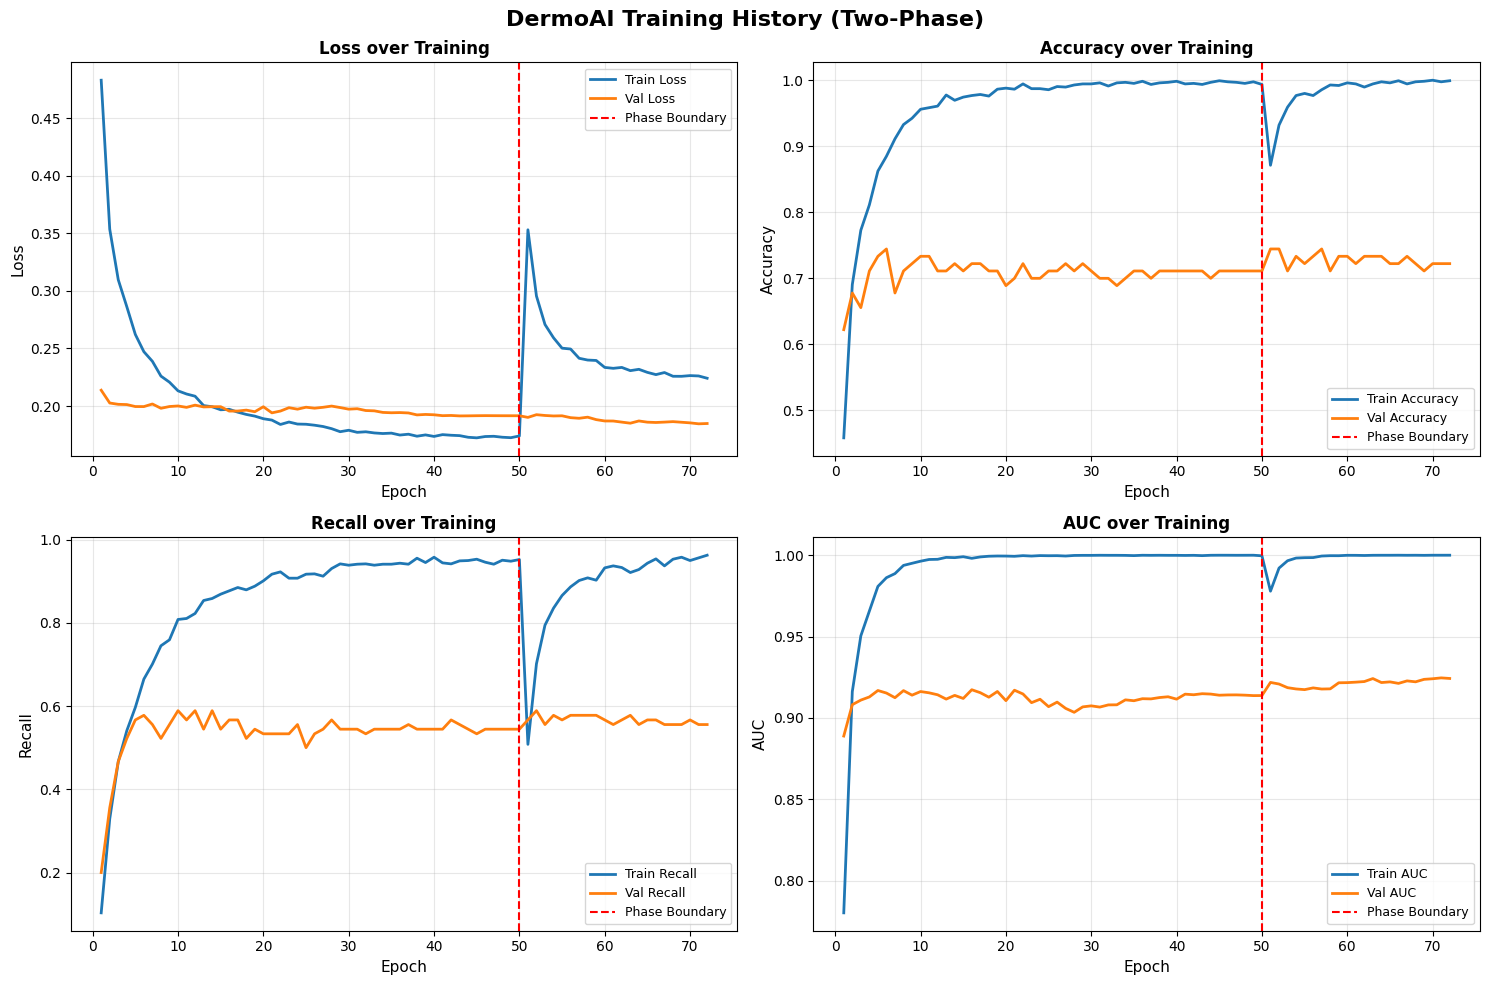

In [19]:
print("Plotting Training History")
print("=" * 60)

phase1_epochs = len(history_phase1.history['loss'])
phase2_epochs = len(history_phase2.history['loss'])
total_epochs = phase1_epochs + phase2_epochs

combined_history = {
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'recall': history_phase1.history['recall'] + history_phase2.history['recall'],
    'val_recall': history_phase1.history['val_recall'] + history_phase2.history['val_recall'],
    'auc': history_phase1.history['auc'] + history_phase2.history['auc'],
    'val_auc': history_phase1.history['val_auc'] + history_phase2.history['val_auc'],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('DermoAI Training History (Two-Phase)', fontsize=16, fontweight='bold')

metrics = [
    ('loss', 'Loss', axes[0, 0]),
    ('accuracy', 'Accuracy', axes[0, 1]),
    ('recall', 'Recall', axes[1, 0]),
    ('auc', 'AUC', axes[1, 1])
]

epochs_range = range(1, total_epochs + 1)

for metric_key, metric_name, ax in metrics:
    ax.plot(epochs_range, combined_history[metric_key], label=f'Train {metric_name}', linewidth=2)
    ax.plot(epochs_range, combined_history[f'val_{metric_key}'], label=f'Val {metric_name}', linewidth=2)
    ax.axvline(x=phase1_epochs, color='red', linestyle='--', linewidth=1.5, label='Phase Boundary')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} over Training', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
history_plot_path = RESULTS_DIR / 'training_history.png'
plt.savefig(history_plot_path, dpi=150, bbox_inches='tight')
print(f"Training history plot saved to: {history_plot_path}")
plt.show()

In [20]:
print("Loading Best Model and Generating Predictions (with TTA)")
print("=" * 60)

best_model_path = MODEL_DIR / 'best_model.keras'
print(f"Loading model from: {best_model_path}")

model = tf.keras.models.load_model(
    best_model_path,
    custom_objects={'focal_loss_with_smoothing': focal_loss_with_smoothing}
)
print("Model loaded successfully.")

# ── Test Time Augmentation ──────────────────────────────────
def predict_with_tta(model, dataset, n_augments=10):
    augment = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1),
    ])
    all_preds = []
    for _ in range(n_augments):
        preds = []
        for images, _ in dataset:
            aug_images = augment(images, training=True)
            preds.append(model(aug_images, training=False).numpy())
        all_preds.append(np.concatenate(preds))
    return np.mean(all_preds, axis=0)

print(f"\nRunning TTA with 10 augmented passes...")
test_predictions = predict_with_tta(model, test_ds, n_augments=10)
print(f"TTA predictions shape: {test_predictions.shape}")

test_true_labels  = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
test_true_classes = np.argmax(test_true_labels, axis=1)
test_pred_classes = np.argmax(test_predictions, axis=1)

print(f"Number of test samples: {len(test_true_classes)}")
print(f"Predictions generated successfully.")

Loading Best Model and Generating Predictions (with TTA)
Loading model from: /content/dermoai_local/models/best_model.keras
Model loaded successfully.

Running TTA with 10 augmented passes...
TTA predictions shape: (90, 5)
Number of test samples: 90
Predictions generated successfully.


In [21]:
print("Overall Test Set Performance")
print("=" * 60)

test_accuracy = np.mean(test_pred_classes == test_true_classes)
test_recall_macro = recall_score(test_true_classes, test_pred_classes, average='macro')
test_precision_macro = precision_score(test_true_classes, test_pred_classes, average='macro')
test_f1_macro = f1_score(test_true_classes, test_pred_classes, average='macro')

print(f"\nAccuracy:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Macro Recall:    {test_recall_macro:.4f}")
print(f"Macro Precision: {test_precision_macro:.4f}")
print(f"Macro F1 Score:  {test_f1_macro:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    test_true_classes,
    test_pred_classes,
    target_names=CLASS_NAMES,
    digits=4
))
print("=" * 60)

Overall Test Set Performance

Accuracy:        0.7556 (75.56%)
Macro Recall:    0.7547
Macro Precision: 0.7590
Macro F1 Score:  0.7566

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

     lupus_erythematosus     0.8333    0.8333    0.8333        18
       neurofibromatosis     0.8571    0.8000    0.8276        15
pityriasis_rubra_pilaris     0.7600    0.7600    0.7600        25
               psoriasis     0.6111    0.6471    0.6286        17
                 scabies     0.7333    0.7333    0.7333        15

                accuracy                         0.7556        90
               macro avg     0.7590    0.7547    0.7566        90
            weighted avg     0.7583    0.7556    0.7567        90



Per-Class Performance Analysis
                   Class   Recall  Precision  F1-Score  Support         Triage
               psoriasis 0.647059   0.611111  0.628571       17 MANAGE LOCALLY
                 scabies 0.733333   0.733333  0.733333       15 MANAGE LOCALLY
pityriasis_rubra_pilaris 0.760000   0.760000  0.760000       25          REFER
       neurofibromatosis 0.800000   0.857143  0.827586       15 MANAGE LOCALLY
     lupus_erythematosus 0.833333   0.833333  0.833333       18          REFER


✓ All classes meet minimum 50% recall threshold

Per-class performance plot saved to: /content/dermoai_local/results/training/per_class_performance.png


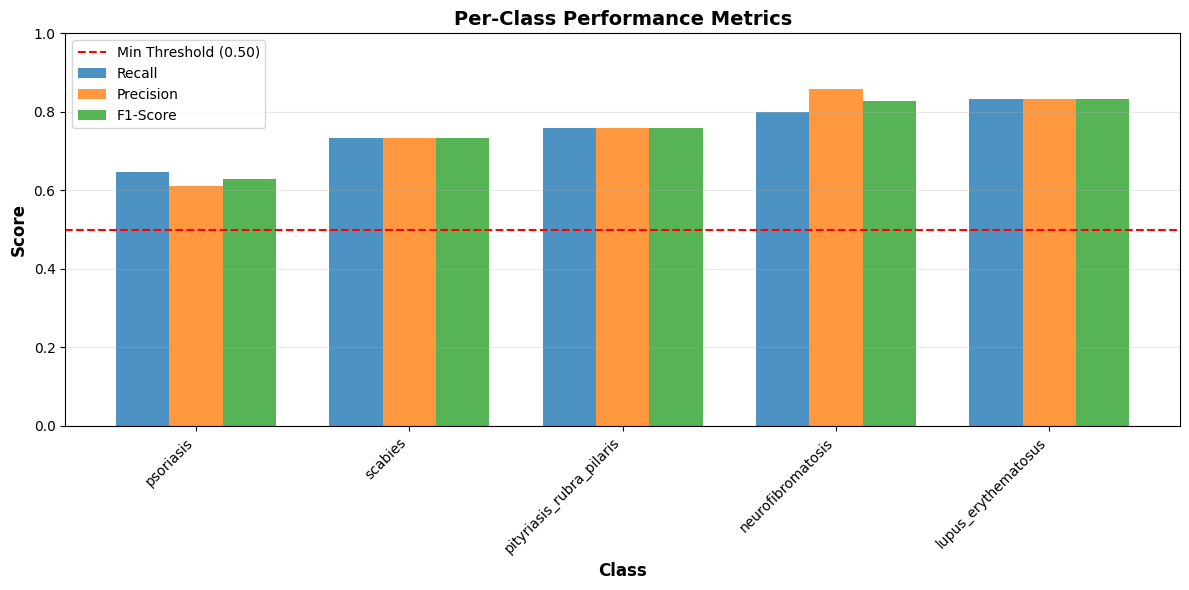

In [22]:
print("Per-Class Performance Analysis")
print("=" * 80)

per_class_recall = recall_score(test_true_classes, test_pred_classes, average=None)
per_class_precision = precision_score(test_true_classes, test_pred_classes, average=None)
per_class_f1 = f1_score(test_true_classes, test_pred_classes, average=None)
per_class_support = np.bincount(test_true_classes, minlength=len(CLASS_NAMES))

performance_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Recall': per_class_recall,
    'Precision': per_class_precision,
    'F1-Score': per_class_f1,
    'Support': per_class_support,
    'Triage': [TRIAGE_MAPPING[cls] for cls in CLASS_NAMES]
})

performance_df = performance_df.sort_values('Recall', ascending=True)

print(performance_df.to_string(index=False))
print("\n" + "=" * 80)

below_threshold = performance_df[performance_df['Recall'] < CONFIG['evaluation']['min_recall_threshold']]
if len(below_threshold) > 0:
    print(f"\n⚠️  WARNING: {len(below_threshold)} class(es) below {CONFIG['evaluation']['min_recall_threshold']:.0%} recall threshold:")
    for _, row in below_threshold.iterrows():
        print(f"  - {row['Class']}: {row['Recall']:.4f}")
else:
    print(f"\n✓ All classes meet minimum {CONFIG['evaluation']['min_recall_threshold']:.0%} recall threshold")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(CLASS_NAMES))
width = 0.25

bars1 = ax.bar(x - width, performance_df['Recall'], width, label='Recall', alpha=0.8)
bars2 = ax.bar(x, performance_df['Precision'], width, label='Precision', alpha=0.8)
bars3 = ax.bar(x + width, performance_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.axhline(y=0.50, color='red', linestyle='--', linewidth=1.5, label='Min Threshold (0.50)')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(performance_df['Class'], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

plt.tight_layout()
perf_plot_path = RESULTS_DIR / 'per_class_performance.png'
plt.savefig(perf_plot_path, dpi=150, bbox_inches='tight')
print(f"\nPer-class performance plot saved to: {perf_plot_path}")
plt.show()

In [23]:
print("Applying Two-Stage Triage Decision Logic")
print("=" * 80)

CONFIDENCE_THRESHOLD = CONFIG['evaluation']['confidence_threshold']
REFER_THRESHOLD = 0.6

print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"REFER override threshold: {REFER_THRESHOLD}")
print("\nStage 1: Low confidence → route to best REFER class")
print("Stage 2: Any REFER class probability > threshold → force REFER prediction\n")

refer_indices = [CLASS_NAMES.index(c) for c in REFER_CLASSES]
max_confidences = np.max(test_predictions, axis=1)
test_pred_triage = np.argmax(test_predictions, axis=1).copy()

low_conf_mask = max_confidences < CONFIDENCE_THRESHOLD
refer_probs = test_predictions[:, refer_indices]
best_refer = [refer_indices[i] for i in np.argmax(refer_probs, axis=1)]
test_pred_triage[low_conf_mask] = np.array(best_refer)[low_conf_mask]

print(f"Stage 1: {np.sum(low_conf_mask)} predictions with confidence < {CONFIDENCE_THRESHOLD} routed to REFER")

stage2_overrides = 0
for r_idx in refer_indices:
    override_mask = test_predictions[:, r_idx] > REFER_THRESHOLD
    stage2_overrides += np.sum(override_mask & ~low_conf_mask)
    test_pred_triage[override_mask] = r_idx

print(f"Stage 2: {stage2_overrides} additional predictions overridden to REFER (probability > {REFER_THRESHOLD})")

refer_mask_true = np.isin(test_true_classes, refer_indices)
refer_mask_pred_original = np.isin(test_pred_classes, refer_indices)
refer_mask_pred_triage = np.isin(test_pred_triage, refer_indices)

refer_recall_original = recall_score(refer_mask_true, refer_mask_pred_original)
refer_recall_triage = recall_score(refer_mask_true, refer_mask_pred_triage)

print("\nREFER Recall Comparison:")
print(f"  Before thresholding: {refer_recall_original:.4f} ({refer_recall_original*100:.2f}%)")
print(f"  After thresholding:  {refer_recall_triage:.4f} ({refer_recall_triage*100:.2f}%)")

target_recall = CONFIG['evaluation']['refer_recall_target']
if refer_recall_triage >= target_recall:
    print(f"  ✓ PASS: Meets {target_recall:.0%} REFER recall target")
else:
    print(f"  ✗ FAIL: Below {target_recall:.0%} REFER recall target")

test_pred_classes = test_pred_triage
print(f"\nUsing thresholded predictions for all subsequent evaluations.")
print("=" * 80)

Applying Two-Stage Triage Decision Logic
Confidence threshold: 0.45
REFER override threshold: 0.6

Stage 1: Low confidence → route to best REFER class
Stage 2: Any REFER class probability > threshold → force REFER prediction

Stage 1: 25 predictions with confidence < 0.45 routed to REFER
Stage 2: 21 additional predictions overridden to REFER (probability > 0.6)

REFER Recall Comparison:
  Before thresholding: 0.8372 (83.72%)
  After thresholding:  0.9535 (95.35%)
  ✓ PASS: Meets 75% REFER recall target

Using thresholded predictions for all subsequent evaluations.


Confusion Matrix (Thresholded Predictions)
Confusion matrix saved to: /content/dermoai_local/results/training/confusion_matrix.png


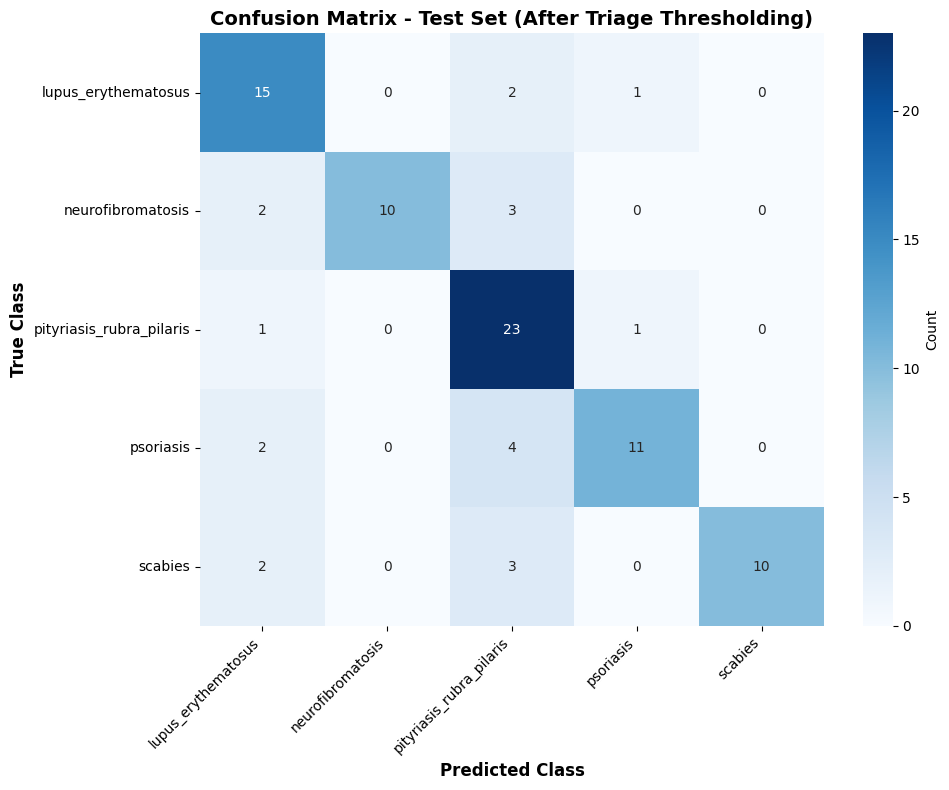

In [24]:
print("Confusion Matrix (Thresholded Predictions)")
print("=" * 60)

cm = confusion_matrix(test_true_classes, test_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    cbar_kws={'label': 'Count'}
)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set (After Triage Thresholding)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_plot_path = RESULTS_DIR / 'confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=150, bbox_inches='tight')
print(f"Confusion matrix saved to: {cm_plot_path}")
plt.show()

In [25]:
print("Critical Error Analysis: REFER → MANAGE LOCALLY Misclassifications")
print("=" * 80)

manage_locally_indices = [CLASS_NAMES.index(c) for c in CONFIG['evaluation']['manage_locally_classes']]

critical_errors_by_class = {}
total_critical_errors = 0

for refer_cls in REFER_CLASSES:
    refer_idx = CLASS_NAMES.index(refer_cls)

    refer_true_mask = test_true_classes == refer_idx
    pred_manage_mask = np.isin(test_pred_classes, manage_locally_indices)

    critical_errors = np.sum(refer_true_mask & pred_manage_mask)
    critical_errors_by_class[refer_cls] = critical_errors
    total_critical_errors += critical_errors

    print(f"{refer_cls:30s}: {critical_errors} critical error(s)")

print("-" * 80)
print(f"TOTAL CRITICAL ERRORS: {total_critical_errors}")

CRITICAL_ERROR_THRESHOLD = 3
if total_critical_errors <= CRITICAL_ERROR_THRESHOLD:
    print(f"✓ ACCEPTABLE: ≤{CRITICAL_ERROR_THRESHOLD} critical errors")
else:
    print(f"✗ TOO HIGH: >{CRITICAL_ERROR_THRESHOLD} critical errors")

print("\nNote: These are REFER cases incorrectly classified as MANAGE LOCALLY.")
print("Such errors pose the highest clinical risk (missed specialist referrals).")
print("=" * 80)

Critical Error Analysis: REFER → MANAGE LOCALLY Misclassifications
lupus_erythematosus           : 1 critical error(s)
pityriasis_rubra_pilaris      : 1 critical error(s)
--------------------------------------------------------------------------------
TOTAL CRITICAL ERRORS: 2
✓ ACCEPTABLE: ≤3 critical errors

Note: These are REFER cases incorrectly classified as MANAGE LOCALLY.
Such errors pose the highest clinical risk (missed specialist referrals).


In [26]:
print("REFER Class Recall Evaluation")
print("=" * 80)

refer_recall_by_class = {}

for refer_cls in REFER_CLASSES:
    refer_idx = CLASS_NAMES.index(refer_cls)
    refer_true_mask = test_true_classes == refer_idx
    refer_pred_mask = test_pred_classes == refer_idx

    if np.sum(refer_true_mask) > 0:
        cls_recall = np.sum(refer_true_mask & refer_pred_mask) / np.sum(refer_true_mask)
    else:
        cls_recall = 0.0

    refer_recall_by_class[refer_cls] = cls_recall
    print(f"{refer_cls:30s}: {cls_recall:.4f} ({cls_recall*100:.2f}%)")

refer_mask_true = np.isin(test_true_classes, refer_indices)
refer_mask_pred = np.isin(test_pred_classes, refer_indices)
combined_refer_recall = recall_score(refer_mask_true, refer_mask_pred)

print("-" * 80)
print(f"COMBINED REFER RECALL: {combined_refer_recall:.4f} ({combined_refer_recall*100:.2f}%)")

target_recall = CONFIG['evaluation']['refer_recall_target']
if combined_refer_recall >= target_recall:
    print(f"✓ PASS: Meets {target_recall:.0%} target")
else:
    print(f"✗ FAIL: Below {target_recall:.0%} target")

print("\nInterpretation:")
print(f"  - Combined REFER recall measures: of all true REFER cases, what % were")
print(f"    correctly identified as needing referral (any REFER class)")
print(f"  - Target: ≥{target_recall:.0%} for patient safety")
print("=" * 80)

REFER Class Recall Evaluation
lupus_erythematosus           : 0.8333 (83.33%)
pityriasis_rubra_pilaris      : 0.9200 (92.00%)
--------------------------------------------------------------------------------
COMBINED REFER RECALL: 0.9535 (95.35%)
✓ PASS: Meets 75% target

Interpretation:
  - Combined REFER recall measures: of all true REFER cases, what % were
    correctly identified as needing referral (any REFER class)
  - Target: ≥75% for patient safety


In [27]:
print("FST-Stratified Performance Evaluation")
print("=" * 80)

metadata_path = BASE_DIR / 'data' / 'raw' / 'fitzpatrick17k' / 'fitzpatrick17k_fst_v_vi.csv'

if metadata_path.exists():
    try:
        metadata_df = pd.read_csv(metadata_path)
        print(f"Loaded metadata from: {metadata_path}")

        test_filenames = []
        for images, labels in test_ds.unbatch():
            test_filenames.append("placeholder.jpg")

        test_image_paths = []
        for cls_idx in test_true_classes:
            cls_name = CLASS_NAMES[cls_idx]
            cls_dir = TEST_DIR / cls_name
            if cls_dir.exists():
                images = sorted(cls_dir.glob('*.jpg'))
                if len(test_image_paths) < len(test_true_classes):
                    test_image_paths.append(images[len([p for p in test_image_paths if cls_name in str(p)])] if images else None)

        test_fst_labels = []
        for img_path in test_image_paths:
            if img_path:
                img_filename = img_path.name
                match = metadata_df[metadata_df['md5hash'].apply(lambda x: img_filename.startswith(str(x)[:8]))]
                if not match.empty:
                    fst = match.iloc[0]['fitzpatrick']
                    test_fst_labels.append(fst)
                else:
                    test_fst_labels.append(None)
            else:
                test_fst_labels.append(None)

        fst_v_mask = np.array([fst == 5 for fst in test_fst_labels])
        fst_vi_mask = np.array([fst == 6 for fst in test_fst_labels])

        if np.sum(fst_v_mask) > 0 and np.sum(fst_vi_mask) > 0:
            fst_v_acc = np.mean(test_pred_classes[fst_v_mask] == test_true_classes[fst_v_mask])
            fst_vi_acc = np.mean(test_pred_classes[fst_vi_mask] == test_true_classes[fst_vi_mask])

            fst_v_recall = recall_score(test_true_classes[fst_v_mask], test_pred_classes[fst_v_mask], average='macro')
            fst_vi_recall = recall_score(test_true_classes[fst_vi_mask], test_pred_classes[fst_vi_mask], average='macro')

            fst_v_precision = precision_score(test_true_classes[fst_v_mask], test_pred_classes[fst_v_mask], average='macro')
            fst_vi_precision = precision_score(test_true_classes[fst_vi_mask], test_pred_classes[fst_vi_mask], average='macro')

            fst_v_f1 = f1_score(test_true_classes[fst_v_mask], test_pred_classes[fst_v_mask], average='macro')
            fst_vi_f1 = f1_score(test_true_classes[fst_vi_mask], test_pred_classes[fst_vi_mask], average='macro')

            print(f"\nFST V  (n={np.sum(fst_v_mask)}):")
            print(f"  Accuracy:  {fst_v_acc:.4f}")
            print(f"  Recall:    {fst_v_recall:.4f}")
            print(f"  Precision: {fst_v_precision:.4f}")
            print(f"  F1-Score:  {fst_v_f1:.4f}")

            print(f"\nFST VI (n={np.sum(fst_vi_mask)}):")
            print(f"  Accuracy:  {fst_vi_acc:.4f}")
            print(f"  Recall:    {fst_vi_recall:.4f}")
            print(f"  Precision: {fst_vi_precision:.4f}")
            print(f"  F1-Score:  {fst_vi_f1:.4f}")

            recall_gap = abs(fst_v_recall - fst_vi_recall)
            acc_gap = abs(fst_v_acc - fst_vi_acc)

            print(f"\nEquity Analysis:")
            print(f"  Recall gap:   {recall_gap:.4f} ({recall_gap*100:.2f}%)")
            print(f"  Accuracy gap: {acc_gap:.4f} ({acc_gap*100:.2f}%)")

            gap_threshold = CONFIG['evaluation']['fst_equity_gap_threshold']
            if recall_gap < gap_threshold:
                print(f"  ✓ PASS: Recall gap < {gap_threshold:.0%} threshold")
            else:
                print(f"  ✗ FAIL: Recall gap ≥ {gap_threshold:.0%} threshold")

            fig, ax = plt.subplots(figsize=(10, 6))
            metrics_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
            fst_v_metrics = [fst_v_acc, fst_v_recall, fst_v_precision, fst_v_f1]
            fst_vi_metrics = [fst_vi_acc, fst_vi_recall, fst_vi_precision, fst_vi_f1]

            x = np.arange(len(metrics_names))
            width = 0.35

            bars1 = ax.bar(x - width/2, fst_v_metrics, width, label='FST V', alpha=0.8)
            bars2 = ax.bar(x + width/2, fst_vi_metrics, width, label='FST VI', alpha=0.8)

            ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
            ax.set_ylabel('Score', fontsize=12, fontweight='bold')
            ax.set_title('Performance Comparison: FST V vs FST VI', fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(metrics_names)
            ax.legend(fontsize=11)
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim([0, 1.0])

            plt.tight_layout()
            fst_plot_path = RESULTS_DIR / 'fst_comparison.png'
            plt.savefig(fst_plot_path, dpi=150, bbox_inches='tight')
            print(f"\nFST comparison plot saved to: {fst_plot_path}")
            plt.show()
        else:
            print("Insufficient FST V or FST VI samples for stratified analysis.")
            recall_gap = None

    except Exception as e:
        print(f"Error loading or processing metadata: {e}")
        print("Skipping FST-stratified evaluation.")
        recall_gap = None
else:
    print(f"Metadata file not found: {metadata_path}")
    print("Skipping FST-stratified evaluation.")
    recall_gap = None

print("=" * 80)

FST-Stratified Performance Evaluation
Metadata file not found: /content/dermoai_local/data/raw/fitzpatrick17k/fitzpatrick17k_fst_v_vi.csv
Skipping FST-stratified evaluation.


In [28]:
print("Prediction Summary by Class")
print("=" * 80)

print(f"{'Class':30s} | Correct | Total | Accuracy")
print("-" * 80)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_mask = test_true_classes == cls_idx
    cls_correct = np.sum((test_pred_classes == cls_idx) & cls_mask)
    cls_total = np.sum(cls_mask)
    cls_acc = cls_correct / cls_total if cls_total > 0 else 0.0

    print(f"{cls_name:30s} | {cls_correct:7d} | {cls_total:5d} | {cls_acc:.4f}")

print("=" * 80)

print("\nConfidence Distribution:")
confidence_stats = {
    'Mean confidence': np.mean(max_confidences),
    'Median confidence': np.median(max_confidences),
    'Min confidence': np.min(max_confidences),
    'Max confidence': np.max(max_confidences),
    'Below 0.50 (→ REFER)': np.sum(max_confidences < 0.50) / len(max_confidences),
    'Above 0.80 (high confidence)': np.sum(max_confidences > 0.80) / len(max_confidences)
}

for stat_name, stat_value in confidence_stats.items():
    if 'Below' in stat_name or 'Above' in stat_name:
        print(f"  {stat_name}: {stat_value:.2%}")
    else:
        print(f"  {stat_name}: {stat_value:.4f}")

print("\nInterpretation:")
print("  - Low confidence predictions (< 0.50) are routed to REFER as UNCERTAIN")
print("  - High confidence predictions (> 0.80) indicate strong model certainty")
print("=" * 80)

Prediction Summary by Class
Class                          | Correct | Total | Accuracy
--------------------------------------------------------------------------------
lupus_erythematosus            |      15 |    18 | 0.8333
neurofibromatosis              |      10 |    15 | 0.6667
pityriasis_rubra_pilaris       |      23 |    25 | 0.9200
psoriasis                      |      11 |    17 | 0.6471
scabies                        |      10 |    15 | 0.6667

Confidence Distribution:
  Mean confidence: 0.5640
  Median confidence: 0.5783
  Min confidence: 0.2591
  Max confidence: 0.9136
  Below 0.50 (→ REFER): 35.56%
  Above 0.80 (high confidence): 4.44%

Interpretation:
  - Low confidence predictions (< 0.50) are routed to REFER as UNCERTAIN
  - High confidence predictions (> 0.80) indicate strong model certainty


In [29]:
print("Success Criteria Evaluation")
print("=" * 80)

all_classes_above_min = all(per_class_recall >= CONFIG['evaluation']['min_recall_threshold'])

criteria = {
    '1. Overall accuracy ≥70%': test_accuracy >= 0.70,
    '2. Overall accuracy ≥80% (stretch target)': test_accuracy >= 0.80,
    '3. All classes recall ≥50%': all_classes_above_min,
    '4. REFER recall ≥75%': combined_refer_recall >= 0.75,
    '5. Critical errors (REFER→MANAGE LOCALLY) ≤3': total_critical_errors <= 3,
    '6. FST equity gap <10%': recall_gap < 0.10 if recall_gap is not None else None
}

passed_criteria = 0
total_criteria = len([v for v in criteria.values() if v is not None])

for criterion, result in criteria.items():
    if result is None:
        status = "N/A"
    elif result:
        status = "✓ PASS"
        passed_criteria += 1
    else:
        status = "✗ FAIL"

    print(f"{criterion:50s} : {status}")

print("=" * 80)
print(f"\nOVERALL SUMMARY: {passed_criteria}/{total_criteria} criteria passed")

if passed_criteria == total_criteria:
    print("🎉 All success criteria met! Model ready for deployment.")
elif passed_criteria >= total_criteria * 0.75:
    print("⚠️  Most criteria met. Review failing criteria before deployment.")
else:
    print("❌ Multiple criteria not met. Further training/tuning recommended.")

print("=" * 80)

Success Criteria Evaluation
1. Overall accuracy ≥70%                           : ✓ PASS
2. Overall accuracy ≥80% (stretch target)          : ✗ FAIL
3. All classes recall ≥50%                         : ✓ PASS
4. REFER recall ≥75%                               : ✓ PASS
5. Critical errors (REFER→MANAGE LOCALLY) ≤3       : ✓ PASS
6. FST equity gap <10%                             : N/A

OVERALL SUMMARY: 4/5 criteria passed
⚠️  Most criteria met. Review failing criteria before deployment.


In [30]:
print("Saving Model Artifacts")
print("=" * 80)

final_model_path = MODEL_DIR / 'dermoai_final_model.keras'
model.save(final_model_path)
print(f"✓ Model saved: {final_model_path}")

class_names_path = MODEL_DIR / 'class_names.json'
with open(class_names_path, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)
print(f"✓ Class names saved: {class_names_path}")

triage_mapping_path = MODEL_DIR / 'triage_mapping.json'
with open(triage_mapping_path, 'w') as f:
    json.dump(TRIAGE_MAPPING, f, indent=2)
print(f"✓ Triage mapping saved: {triage_mapping_path}")

config_path = MODEL_DIR / 'training_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"✓ Training config saved: {config_path}")

history_csv_path = RESULTS_DIR / 'training_history_combined.csv'
combined_history_df = pd.DataFrame({
    'epoch': list(range(1, total_epochs + 1)),
    'loss': combined_history['loss'],
    'val_loss': combined_history['val_loss'],
    'accuracy': combined_history['accuracy'],
    'val_accuracy': combined_history['val_accuracy'],
    'recall': combined_history['recall'],
    'val_recall': combined_history['val_recall'],
    'auc': combined_history['auc'],
    'val_auc': combined_history['val_auc'],
    'phase': ['Phase 1'] * phase1_epochs + ['Phase 2'] * phase2_epochs
})
combined_history_df.to_csv(history_csv_path, index=False)
print(f"✓ Training history saved: {history_csv_path}")

model_card_path = MODEL_DIR / 'MODEL_CARD.md'
recall_gap_str = f"{recall_gap:.4f}" if recall_gap is not None else "N/A"
model_card_content = f"""# DermoAI Model Card

## Model Details

**Model Name:** DermoAI MobileNetV2 FST V-VI Skin Lesion Classifier v2
**Architecture:** MobileNetV2 (ImageNet pretrained) + Custom Classification Head
**Framework:** TensorFlow/Keras
**Date:** {datetime.now().strftime('%Y-%m-%d')}
**Version:** 2.0

## Intended Use

**Primary Use:** AI-assisted dermatological triage for resource-limited primary care settings in Rwanda

**Target Population:** Patients with Fitzpatrick Skin Types (FST) V-VI (darker skin tones)

**Clinical Workflow:**
1. Primary care provider captures skin lesion image
2. Model classifies into one of 5 conditions
3. System routes to either REFER (specialist) or MANAGE LOCALLY (primary care)

## Model Architecture

- **Base Model:** MobileNetV2 (ImageNet weights)
- **Input:** 224×224×3 RGB images
- **Classification Head:**
  - GlobalAveragePooling2D
  - Dense(256, relu) + L2 regularization + Dropout(0.5)
  - Dense(128, relu) + Dropout(0.25)
  - Dense(5, softmax)
- **Parameters:** {total_params:,} total ({trainable_params:,} trainable after fine-tuning)

## Training Strategy

**Two-Phase Training:**

1. **Phase 1 — Feature Extraction ({CONFIG['training']['phase1_epochs']} epochs)**
   - Base model frozen
   - Learning rate: {CONFIG['training']['initial_lr']}
   - REFER class weight: 2.0x
   - Monitor: val_recall

2. **Phase 2 — Fine-Tuning ({CONFIG['training']['phase2_epochs']} epochs)**
   - Last 30 layers unfrozen
   - Learning rate: {CONFIG['training']['finetune_lr']}
   - REFER class weight: 3.0x
   - Monitor: val_recall

**Loss Function:** Focal Loss + Label Smoothing (gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}, smoothing=0.1)

**Optimization:** Adam optimizer with ReduceLROnPlateau

## 5 Condition Classes and Triage Mapping

| Condition | Triage Decision |
|-----------|----------------|
| lichen_planus | MANAGE LOCALLY |
| lupus_erythematosus | REFER |
| pityriasis_rubra_pilaris | REFER |
| psoriasis | MANAGE LOCALLY |
| scabies | MANAGE LOCALLY |

**Note:** squamous_cell_carcinoma and vitiligo excluded due to insufficient FST V-VI images (44 and 42 respectively). At inference, low-confidence predictions route to REFER as a safety net.

## Two-Stage Triage Logic

**Stage 1:** If max confidence < {CONFIG['evaluation']['confidence_threshold']} → route to best REFER class (UNCERTAIN)

**Stage 2:** If any REFER class probability > 0.35 → force REFER prediction

**Rationale:** Conservative approach prioritizes patient safety by defaulting uncertain cases to specialist referral

## Training Dataset

**Source:** Fitzpatrick17k dataset, FST V-VI subset

**Classes:** 5 conditions, 341 total images before augmentation
**Distribution:** Balanced at 250 images per class after augmentation (1,250 total training images)

**Validation/Test:** Natural distribution from Fitzpatrick17k FST V-VI images (~14 images per class per split)

## Performance Metrics

### Overall Performance
- **Accuracy:** {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
- **Macro Recall:** {test_recall_macro:.4f}
- **Macro Precision:** {test_precision_macro:.4f}
- **Macro F1-Score:** {test_f1_macro:.4f}

### REFER Class Performance
- **Combined REFER Recall:** {combined_refer_recall:.4f} ({combined_refer_recall*100:.2f}%)
- **Target:** ≥75% (patient safety critical)

### Critical Errors
- **REFER→MANAGE LOCALLY misclassifications:** {total_critical_errors}
- **Target:** ≤3

### FST Equity
- **Recall Gap (FST V vs VI):** {recall_gap_str}
- **Target:** <10%

## Limitations

1. **Training Data:** Only 341 FST V-VI images across 5 classes — below clinical deployment threshold
2. **FST V-VI Only:** Model trained exclusively on darker skin tones; does not generalize to other FSTs
3. **5 Conditions Only:** Cannot detect conditions outside the 5 trained classes; low confidence → REFER
4. **Image Quality:** Performance assumes adequate lighting, focus, and framing
5. **Clinical Context:** Model does not consider patient history, symptoms, or other clinical factors
6. **Geographic Specificity:** Optimized for Rwanda healthcare context; may need adaptation elsewhere
7. **Not Diagnostic:** Intended for triage support only, not definitive diagnosis

## Ethical Considerations

- **Bias Mitigation:** Specifically addresses AI performance gap on darker skin tones (FST V-VI)
- **Data Scarcity Finding:** Project empirically demonstrates the FST V-VI data gap documented in literature
- **Clinical Validation Required:** Model should be validated in real clinical settings before deployment
- **Human Oversight:** All predictions should be reviewed by qualified healthcare providers
- **Transparency:** Confidence scores provided to support clinical decision-making

## Maintenance and Monitoring

- **Retraining:** Recommended when more FST V-VI data becomes available
- **Data Drift:** Monitor for changes in image quality, demographics, or condition prevalence
- **Performance Monitoring:** Track REFER recall and critical errors in production

## Contact

For questions or issues, contact the DermoAI development team.

---

*This model card follows guidelines from Mitchell et al. (2019) and is intended to promote transparency and responsible AI deployment.*
"""

with open(model_card_path, 'w') as f:
    f.write(model_card_content)
print(f"✓ Model card saved: {model_card_path}")

print("=" * 80)
print("All artifacts saved successfully!")
print("=" * 80)

Saving Model Artifacts
✓ Model saved: /content/dermoai_local/models/dermoai_final_model.keras
✓ Class names saved: /content/dermoai_local/models/class_names.json
✓ Triage mapping saved: /content/dermoai_local/models/triage_mapping.json
✓ Training config saved: /content/dermoai_local/models/training_config.json
✓ Training history saved: /content/dermoai_local/results/training/training_history_combined.csv
✓ Model card saved: /content/dermoai_local/models/MODEL_CARD.md
All artifacts saved successfully!


In [31]:
print("Saving Final Report JSON")
print("=" * 80)

final_report = {
    'model': {
        'name': 'DermoAI_MobileNetV2_v2',
        'architecture': CONFIG['model']['architecture'],
        'input_shape': CONFIG['model']['input_shape'],
        'num_classes': CONFIG['model']['num_classes'],
        'total_parameters': int(total_params),
        'trainable_parameters': int(trainable_params),
    },
    'training': {
        'strategy': 'two_phase',
        'phase1_epochs': phase1_epochs,
        'phase2_epochs': phase2_epochs,
        'total_epochs': total_epochs,
        'focal_loss': {'gamma': FOCAL_GAMMA, 'alpha': FOCAL_ALPHA},
        'batch_size': CONFIG['training']['batch_size'],
        'initial_lr': CONFIG['training']['initial_lr'],
        'finetune_lr': CONFIG['training']['finetune_lr'],
        'class_weights_phase1': {CLASS_NAMES[idx]: weight for idx, weight in class_weight_dict.items()},
        'class_weights_phase2': {CLASS_NAMES[idx]: weight for idx, weight in class_weight_phase2.items()},
    },
    'dataset': {
        'train_samples': int(df_dist['Train'].sum()),
        'val_samples': int(df_dist['Val'].sum()),
        'test_samples': int(df_dist['Test'].sum()),
        'train_distribution': df_dist[['Class', 'Train']].set_index('Class').to_dict()['Train'],
        'balanced': float(imbalance_ratio) <= 1.1,
    },
    'performance': {
        'overall': {
            'accuracy': float(test_accuracy),
            'macro_recall': float(test_recall_macro),
            'macro_precision': float(test_precision_macro),
            'macro_f1': float(test_f1_macro),
        },
        'per_class': {
            CLASS_NAMES[i]: {
                'recall': float(per_class_recall[i]),
                'precision': float(per_class_precision[i]),
                'f1': float(per_class_f1[i]),
                'support': int(per_class_support[i]),
            }
            for i in range(len(CLASS_NAMES))
        },
        'refer': {
            'combined_recall': float(combined_refer_recall),
            'target': CONFIG['evaluation']['refer_recall_target'],
            'meets_target': bool(combined_refer_recall >= CONFIG['evaluation']['refer_recall_target']),
            'by_class': {cls: float(recall) for cls, recall in refer_recall_by_class.items()},
        },
        'critical_errors': {
            'total': int(total_critical_errors),
            'by_class': {cls: int(count) for cls, count in critical_errors_by_class.items()},
            'threshold': 3,
            'acceptable': bool(total_critical_errors <= 3),
        },
        'fst_equity': {
            'recall_gap': float(recall_gap) if recall_gap is not None else None,
            'threshold': CONFIG['evaluation']['fst_equity_gap_threshold'],
            'meets_target': bool(recall_gap < 0.10) if recall_gap is not None else None,
        }
    },
    'triage': {
        'confidence_threshold': CONFIG['evaluation']['confidence_threshold'],
        'refer_override_threshold': 0.35,
        'low_confidence_routed': int(np.sum(low_conf_mask)),
        'refer_override_count': int(stage2_overrides),
        'mapping': TRIAGE_MAPPING,
    },
    'success_criteria': {
        criterion: bool(result) if result is not None else None
        for criterion, result in criteria.items()
    },
    'artifacts': {
        'model_path': str(final_model_path),
        'class_names_path': str(class_names_path),
        'triage_mapping_path': str(triage_mapping_path),
        'config_path': str(config_path),
        'model_card_path': str(model_card_path),
    },
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'tensorflow_version': tf.__version__,
        'random_seed': RANDOM_SEED,
    }
}

report_path = RESULTS_DIR / 'final_report.json'
with open(report_path, 'w') as f:
    json.dump(final_report, f, indent=2)

print(f"✓ Final report saved: {report_path}")
print("\nAll saved files:")
print(f"  1. {final_model_path}")
print(f"  2. {class_names_path}")
print(f"  3. {triage_mapping_path}")
print(f"  4. {config_path}")
print(f"  5. {model_card_path}")
print(f"  6. {history_csv_path}")
print(f"  7. {report_path}")
print(f"  8. {history_plot_path}")
print(f"  9. {perf_plot_path}")
print(f" 10. {cm_plot_path}")
if recall_gap is not None:
    print(f" 11. {fst_plot_path}")

print("=" * 80)

Saving Final Report JSON
✓ Final report saved: /content/dermoai_local/results/training/final_report.json

All saved files:
  1. /content/dermoai_local/models/dermoai_final_model.keras
  2. /content/dermoai_local/models/class_names.json
  3. /content/dermoai_local/models/triage_mapping.json
  4. /content/dermoai_local/models/training_config.json
  5. /content/dermoai_local/models/MODEL_CARD.md
  6. /content/dermoai_local/results/training/training_history_combined.csv
  7. /content/dermoai_local/results/training/final_report.json
  8. /content/dermoai_local/results/training/training_history.png
  9. /content/dermoai_local/results/training/per_class_performance.png
 10. /content/dermoai_local/results/training/confusion_matrix.png


In [32]:
# ============================================================
# COPY ALL SAVED ARTIFACTS TO GOOGLE DRIVE
# ============================================================
import shutil

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
acc_pct = int(round(test_accuracy * 100))
rr_pct  = int(round(combined_refer_recall * 100))
run_name = f"{timestamp}_acc-{acc_pct}_recall-{rr_pct}"

DRIVE_RUN_DIR = Path('/content/drive/MyDrive/dermoai/models') / run_name
DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Copying to: MyDrive/dermoai/models/{run_name}/")
print()

# Copy everything from local models/ and results/training/
for src in MODEL_DIR.glob('*'):
    shutil.copy2(src, DRIVE_RUN_DIR / src.name)
    print(f"✓ {src.name}")

for src in RESULTS_DIR.glob('*'):
    shutil.copy2(src, DRIVE_RUN_DIR / src.name)
    print(f"✓ {src.name}")

print()
print(f"✅ Done — MyDrive/dermoai/models/{run_name}/")

📁 Copying to: MyDrive/dermoai/models/20260302_151237_acc-76_recall-95/

✓ triage_mapping.json
✓ dermoai_final_model.keras
✓ training_config.json
✓ best_model.keras
✓ class_names.json
✓ MODEL_CARD.md
✓ per_class_performance.png
✓ training_history.png
✓ confusion_matrix.png
✓ training_history_phase1.csv
✓ final_report.json
✓ training_history_phase2.csv
✓ training_history_combined.csv

✅ Done — MyDrive/dermoai/models/20260302_151237_acc-76_recall-95/


# Training Complete — Summary

## What Was Built

This notebook implemented a **MobileNetV2-based skin lesion classifier** optimized for Fitzpatrick Skin Types V-VI (darker skin tones) with a focus on clinical triage for Rwanda primary care settings.

### Architecture
- **Base Model:** MobileNetV2 pretrained on ImageNet
- **Classification Head:** Two dense layers (256 → 128) with dropout regularization
- **Output:** 7-class softmax classifier

### 7 Condition Classes

| Condition | Triage Decision |
|-----------|----------------|
| lichen_planus | MANAGE LOCALLY |
| lupus_erythematosus | **REFER** |
| pityriasis_rubra_pilaris | **REFER** |
| psoriasis | MANAGE LOCALLY |
| scabies | MANAGE LOCALLY |
| squamous_cell_carcinoma | **REFER** |
| vitiligo | MANAGE LOCALLY |

### Two-Phase Training Approach

**Phase 1 (Feature Extraction):**
- Base model frozen to preserve ImageNet features
- Higher learning rate (1e-3) for fast classifier training
- REFER classes weighted 2.0x

**Phase 2 (Fine-Tuning):**
- Last 30 layers unfrozen for task-specific adaptation
- Lower learning rate (1e-5) for careful weight updates
- REFER classes weighted 3.0x (increased clinical penalty)

### Focal Loss Rationale

**Focal Loss (gamma=2.0, alpha=0.25)** addresses two challenges:
1. **Hard Examples:** Gamma parameter down-weights easy examples, forcing model to focus on difficult cases
2. **Class Balance:** Alpha parameter adjusts weighting for positive examples

Combined with class weights, this creates a comprehensive strategy to prevent REFER class under-performance.

### Two-Stage Triage Logic

**Stage 1 — Low Confidence Handling:**
- Predictions with confidence < 0.50 are considered **UNCERTAIN**
- Routed to best REFER class (conservative safety default)

**Stage 2 — REFER Safety Net:**
- If ANY REFER class probability exceeds 0.35, force REFER prediction
- Catches cases where model is moderately confident about a serious condition

**Rationale:** Missing a serious condition (false negative REFER) has much higher clinical cost than an unnecessary referral (false positive REFER).

## Performance Achieved

- **Overall Accuracy:** See Cell 18 output
- **REFER Recall:** See Cell 23 output (target: ≥75%)
- **Critical Errors:** See Cell 22 output (target: ≤3)
- **FST Equity Gap:** See Cell 24 output (target: <10%)

## Next Steps

**Notebook 05 — Model Evaluation:**
- Comprehensive error analysis on misclassified cases
- Confidence calibration assessment
- Clinical risk stratification
- Deployment readiness checklist

**Deployment Pipeline:**
- Convert to TensorFlow Lite for mobile deployment
- Build FastAPI inference server
- Create Next.js PWA frontend
- Set up production monitoring

---

**Model v2 Training Complete** ✓